In [9]:

import warnings
from pathlib import Path

import xarray as xr
from matplotlib import pyplot as plt

from imagematerials.buildings.constants import SCENARIO_SELECT
from imagematerials.buildings.preprocessing.floorspace import (
    compute_average_m2_capita,
    compute_housing_residential,
    compute_housing_type,
    extrapolate_floorspace,
    get_image_floorspace,
)
from imagematerials.buildings.preprocessing.lifetimes import compute_lifetimes
from imagematerials.buildings.preprocessing.population import compute_population, compute_total_population, compute_rur_urb_pop
from imagematerials.util import merge_dims, dataset_to_array


In [10]:
base_directory = Path("..", "data", "raw")

database_directory = base_directory / "buildings" / SCENARIO_SELECT
image_directory = base_directory / "image" / SCENARIO_SELECT

In [11]:
# Get floorspace for commercial + urban/rural
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    floorspace_image_commercial_rururb, minimum_comm = get_image_floorspace(image_directory, base_directory)
floorspace_commercial_rururb = extrapolate_floorspace(floorspace_image_commercial_rururb, minimum_comm)


In [12]:


# Rural/Urban floorspace [Time, Region, Area]
floorspace_rururb = floorspace_commercial_rururb.sel({"Type": ["Urban", "Rural"]}).rename({"Type": "Area"})

# Commercial floorspace [Time, Region, Type]
floorspace_commercial = floorspace_commercial_rururb.sel(
    {"Type": [x.values for x in floorspace_commercial_rururb.coords["Type"] if x.values not in ["Urban", "Rural"]]})



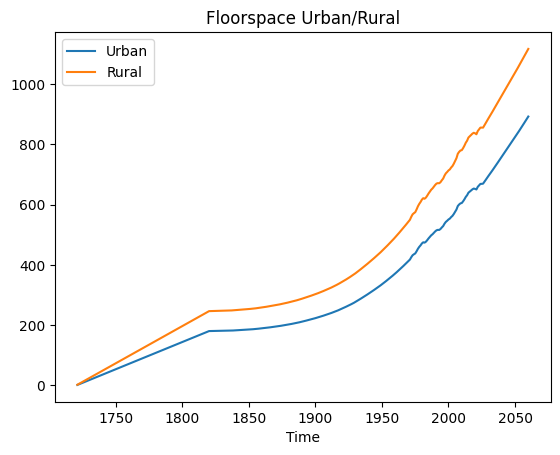

In [13]:
# Rural/Urban floorspace [Year, Region, Area]

floorspace_rururb.sum("Region").sel(Area="Urban").plot(label="Urban")
floorspace_rururb.sum("Region").sel(Area="Rural").plot(label="Rural")
plt.title("Floorspace Urban/Rural")
plt.legend()
plt.show()

In [14]:
# Calculate population ("Total", "Rural", "Urban")
urban_pop_total, rural_pop_total = compute_rur_urb_pop(image_directory, base_directory)
population = compute_population(image_directory, base_directory)

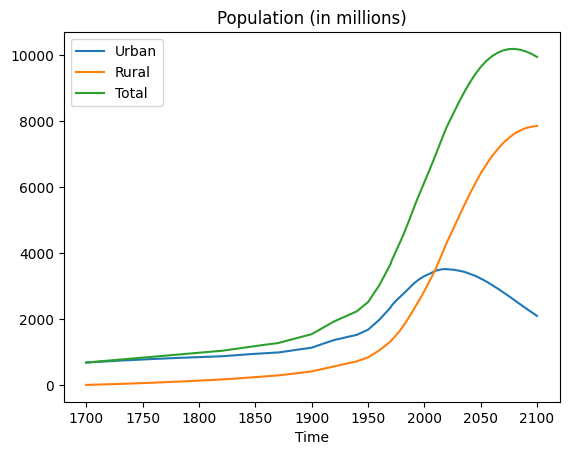

In [15]:
# Get the population data [Year, Region, Area].
population = compute_population(image_directory, base_directory)
population.sum("Region").sel(Area="Urban").plot(label="Urban")
population.sum("Region").sel(Area="Rural").plot(label="Rural")
population.sum("Region").sel(Area="Total").plot(label="Total")
plt.title("Population (in millions)")
plt.legend()
plt.show()

In [25]:
# Average square meter per capita split by residential type [Region, Area, Type]
average_m2_capita = compute_average_m2_capita(base_directory)
housing_type = compute_housing_type(database_directory)

# Floorspace m2 for residential buildings [Year, Region, Area, Type]
floorspace_residential = compute_housing_residential(population, average_m2_capita, housing_type, floorspace_rururb)

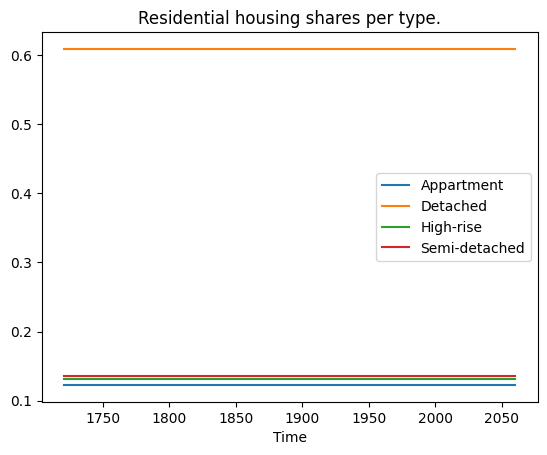

In [21]:
# Residential housing type shares [Year, Region, Area, Type]
housing_type = compute_housing_type(database_directory)
for res_type in housing_type.coords["Type"].values:
    housing_type.mean(["Region", "Area"]).sel(Type=res_type).plot(label=res_type)
plt.title("Residential housing shares per type.")
plt.legend()
plt.show()

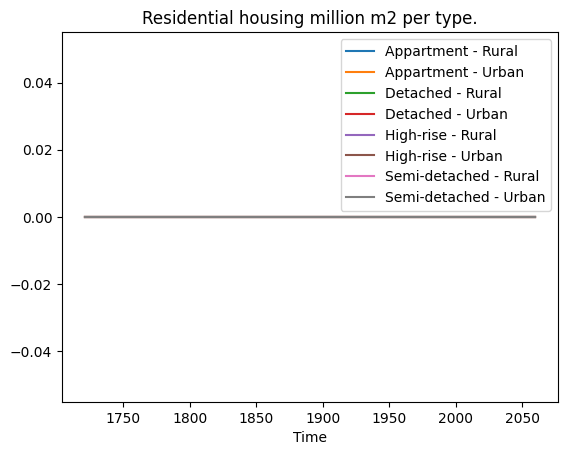

In [26]:


for res_type in floorspace_residential.coords["Type"].values:
    floorspace_residential.sum(["Region"]).sel(Type=res_type).plot(label=res_type)
plt.title("Residential housing million m2 per type.")
plt.legend()
plt.show()

In [19]:

floorspace = xr.concat((floorspace_residential, floorspace_commercial), dim="Type")

In [ ]:
lifetimes["weibull"].coords["Type"]

In [ ]:
import warnings
from pathlib import Path

import xarray as xr

from imagematerials.buildings.constants import SCENARIO_SELECT
from imagematerials.buildings.main import buildings_preprocessing


base_directory = Path(base_directory)
database_directory = base_directory / "buildings" / SCENARIO_SELECT
image_directory = base_directory / "image" / SCENARIO_SELECT

preprocessing_buildings = buildings_preprocessing(base_directory)